<a href="https://colab.research.google.com/github/mnehan67/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Context-Aware Performance Anomaly Ranking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mnehan67/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

## Project

**Title:** Context-Aware Performance Anomaly Ranking: A Leakage-Safe System for Prioritizing High-Impact CTR Underperformance

**Lane:** CTR / Engagement Opportunity Scoring

**Research question:**  
Can a system learn the CTR normally expected from a page's non-click search context, detect pages whose observed CTR falls below that expectation, and rank the highest-impact cases for human review?

**Decision supported:**  
Which visible pages should an editorial / SEO team inspect first when review capacity is limited?

This is an **end-of-period monitoring and prioritization system**, not a claim to predict Google's algorithm and not a claim that editing a page will causally increase traffic.

### Starting evidence from my executed W04 baseline

My March 2026 signal audit produced:

- **101,441** eligible page-month rows across **44 clients**.
- CTR vs. position signal: **CONFIRMED**.
- Volume/confidence signal: **CONFIRMED**.
- The frozen transparent W04 rule produced **22,185** review candidates.
- W04 rule: compare observed CTR with the median CTR of the same position bucket; keep positive gaps with adequate volume; scale the positive gap by impressions.

This notebook now turns that baseline into the full capstone: multi-month modeling, honest validation, final June test, ranked recommendations, figures, metric receipts, and a deployable research-paper page.


## 0. What this notebook will create

Run **top to bottom without changing the frozen settings after seeing June**.

It will create locally in the Colab runtime:

- `work/outputs/capstone_metrics.json` — commit this.
- `work/outputs/final_action_queue.csv` — **do not commit**; it is regenerable data.
- `work/figures/*.png` — commit these.
- `docs/index.html` + `docs/assets/*` — the deployed research paper.
- `submission/paper_url.txt` — mandatory one-line paper URL.
- `capstone_submission_bundle.zip` — convenient bundle of the public-safe files to upload to GitHub.

The raw warehouse is never downloaded into your repo.


In [1]:
# Keep Colab compatible rather than upgrading pandas past Colab's pinned version.
%pip -q install -U duckdb huggingface_hub scikit-learn matplotlib joblib "pandas==2.2.3"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 51.7 MB/s eta 0:00:00


In [2]:
import calendar
import getpass
import json
import math
import os
import platform
import shutil
import sys
import warnings
from pathlib import Path

import duckdb
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from huggingface_hub import HfApi
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd()
WORK = ROOT / "work"
OUTPUTS = WORK / "outputs"
FIGURES = WORK / "figures"
DOCS = ROOT / "docs"
ASSETS = DOCS / "assets"
SUBMISSION = ROOT / "submission"

for p in [OUTPUTS, FIGURES, DOCS, ASSETS, SUBMISSION]:
    p.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("duckdb:", duckdb.__version__)


Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.9.1
duckdb: 1.5.5


## 1. Authenticate to the gated FlyRank warehouse

The token is requested with a hidden prompt and is never written into the notebook, HTML paper, metrics JSON, or output bundle.


In [3]:
HF_TOKEN = getpass.getpass(
    "Paste your Hugging Face plain READ token (hidden; not saved): "
).strip()

if not HF_TOKEN.startswith("hf_"):
    raise RuntimeError(
        "That does not look like a Hugging Face token. "
        "Paste the complete plain Read token beginning with hf_."
    )

try:
    me = HfApi().whoami(token=HF_TOKEN)
    print(f"✓ Token valid for Hugging Face account: {me.get('name', 'unknown')}")
except Exception as e:
    raise RuntimeError(
        "The token is invalid. Create a new plain Read token, restart the runtime, "
        "and run again."
    ) from e

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_ROOT = f"{REL}/fact_content_daily_performance"

probe = con.sql(
    f"SELECT COUNT(*) FROM read_parquet('{FACT_ROOT}/month=2026-03/*.parquet')"
).fetchone()[0]

print(f"✓ Warehouse access works. March contains {probe:,} daily fact rows.")


Paste your Hugging Face plain READ token (hidden; not saved): ··········
✓ Token valid for Hugging Face account: muhnehh
✓ Warehouse access works. March contains 9,841,378 daily fact rows.


## 2. Data contract and frozen experimental design

### Unit
One row in the modeling frame is **one pseudonymized client × content page × calendar month**.

### Source
FlyRank internship warehouse release **v20260703**, table `fact_content_daily_performance`.

### Full-month windows
January 2026 is excluded because the warehouse begins on January 27, so it is not a comparable full calendar month.

- **Train:** February–April 2026
- **Validation / method selection:** May 2026
- **Final sealed test:** June 2026

### Target
`observed_ctr_pp = 100 × clicks / impressions`

CTR is stored and reported in **percentage points**.

### Prediction inputs
Only non-click search-context measurements are used. No click count, CTR copy, future month, product flag, URL, query text, client identity, or content identity is used as a model feature.

### Interpretation
The model estimates **expected same-month CTR given observed non-click context at the end of that month**. Therefore this is contextual performance monitoring, not a before-the-month forecasting claim.

### Frozen primary eligibility
At least **500 monthly impressions** and a valid positive weighted search position.

The data is first aggregated with a 100-impression floor so the final notebook can stress-test 100 / 500 / 1,000 without rescanning the warehouse.


In [4]:
# FROZEN SETTINGS — do not tune these after seeing June.
TRAIN_MONTHS = ["2026-02", "2026-03", "2026-04"]
VALID_MONTH = "2026-05"
TEST_MONTH = "2026-06"
ALL_MONTHS = TRAIN_MONTHS + [VALID_MONTH, TEST_MONTH]

EXTRACT_MIN_IMPRESSIONS = 100
PRIMARY_MIN_IMPRESSIONS = 500
ACTION_MAX_POSITION = 20.0

POSITION_BINS = [0, 3, 10, 20, 50, np.inf]
POSITION_LABELS = [
    "1_top3",
    "2_pos4_10",
    "3_pos11_20",
    "4_pos21_50",
    "5_pos51_plus",
]

FEATURES = [
    "log_impressions",
    "avg_position",
    "days_with_impressions",
    "active_day_fraction",
    "position_volatility",
    "impression_spikiness",
    "daily_impression_cv",
    "log_impression_momentum",
    "position_shift",
]

FORBIDDEN_FEATURE_FRAGMENTS = [
    "click",
    "ctr",
    "client_hash_id",
    "content_hash_id",
    "future",
    "trend_pct",
    "trend_direction",
    "health_score",
    "priority_score",
    "action_type",
]

for f in FEATURES:
    assert not any(bad in f.lower() for bad in FORBIDDEN_FEATURE_FRAGMENTS), f

print("Frozen features:", FEATURES)
print("Primary impression floor:", PRIMARY_MIN_IMPRESSIONS)
print("Train:", TRAIN_MONTHS, "| Validation:", VALID_MONTH, "| Final test:", TEST_MONTH)


Frozen features: ['log_impressions', 'avg_position', 'days_with_impressions', 'active_day_fraction', 'position_volatility', 'impression_spikiness', 'daily_impression_cv', 'log_impression_momentum', 'position_shift']
Primary impression floor: 500
Train: ['2026-02', '2026-03', '2026-04'] | Validation: 2026-05 | Final test: 2026-06


## 3. Build the page-month feature table with DuckDB

This is the only expensive warehouse stage. Each month is aggregated remotely before it enters pandas. The resulting page-month table is cached only in the temporary runtime.


In [5]:
def aggregate_month(month: str) -> pd.DataFrame:
    year, mon = map(int, month.split("-"))
    days_in_month = calendar.monthrange(year, mon)[1]
    source = f"read_parquet('{FACT_ROOT}/month={month}/*.parquet')"

    query = f"""
    WITH daily AS (
        SELECT
            client_hash_id,
            content_hash_id,
            report_date,
            gsc_impressions,
            gsc_clicks,
            gsc_sum_position,
            gsc_avg_position,
            EXTRACT(DAY FROM report_date) AS day_of_month
        FROM {source}
        WHERE gsc_data_available IS TRUE
    ),
    agg AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS impressions,
            SUM(gsc_clicks) AS clicks,
            SUM(gsc_sum_position) AS sum_position,

            COUNT(*) FILTER (
                WHERE gsc_impressions > 0
            ) AS days_with_impressions,

            STDDEV_POP(gsc_avg_position) FILTER (
                WHERE gsc_impressions > 0
            ) AS position_volatility,

            MAX(gsc_impressions) AS max_daily_impressions,

            AVG(gsc_impressions) FILTER (
                WHERE gsc_impressions > 0
            ) AS mean_daily_active_impressions,

            STDDEV_POP(gsc_impressions) FILTER (
                WHERE gsc_impressions > 0
            ) AS std_daily_active_impressions,

            SUM(gsc_impressions) FILTER (
                WHERE day_of_month <= 15
            ) AS impressions_first_half,

            SUM(gsc_impressions) FILTER (
                WHERE day_of_month > 15
            ) AS impressions_second_half,

            SUM(gsc_sum_position) FILTER (
                WHERE day_of_month <= 15
            ) AS sum_position_first_half,

            SUM(gsc_sum_position) FILTER (
                WHERE day_of_month > 15
            ) AS sum_position_second_half
        FROM daily
        GROUP BY 1, 2
    )
    SELECT
        client_hash_id,
        content_hash_id,
        '{month}' AS month,
        impressions,
        clicks,
        sum_position / NULLIF(impressions, 0) AS avg_position,
        100.0 * clicks / NULLIF(impressions, 0) AS observed_ctr_pp,
        days_with_impressions,
        {days_in_month} AS days_in_month,
        COALESCE(position_volatility, 0.0) AS position_volatility,
        max_daily_impressions / NULLIF(impressions, 0) AS impression_spikiness,
        std_daily_active_impressions / NULLIF(mean_daily_active_impressions, 0)
            AS daily_impression_cv,

        LN(1 + impressions) AS log_impressions,

        days_with_impressions::DOUBLE / {days_in_month}
            AS active_day_fraction,

        LN(
            (1 + COALESCE(impressions_second_half, 0))
            / (1 + COALESCE(impressions_first_half, 0))
        ) AS log_impression_momentum,

        (
            sum_position_second_half / NULLIF(impressions_second_half, 0)
        ) - (
            sum_position_first_half / NULLIF(impressions_first_half, 0)
        ) AS position_shift

    FROM agg
    WHERE impressions >= {EXTRACT_MIN_IMPRESSIONS}
      AND sum_position > 0
    """

    df = con.sql(query).df()
    print(
        f"✓ {month}: {len(df):,} page-month rows | "
        f"{df['client_hash_id'].nunique():,} clients"
    )
    return df


frames = []
for month in ALL_MONTHS:
    frames.append(aggregate_month(month))

panel = pd.concat(frames, ignore_index=True)

panel["position_bucket"] = pd.cut(
    panel["avg_position"],
    bins=POSITION_BINS,
    labels=POSITION_LABELS,
    right=True,
)

assert panel.duplicated(["month", "client_hash_id", "content_hash_id"]).sum() == 0
assert panel["observed_ctr_pp"].between(0, 100).all()

print("\nCombined page-month frame:", panel.shape)
display(
    panel.groupby("month", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        clients=("client_hash_id", "nunique"),
        median_impressions=("impressions", "median"),
        median_ctr_pp=("observed_ctr_pp", "median"),
    )
    .reset_index()
)


✓ 2026-02: 80,321 page-month rows | 37 clients
✓ 2026-03: 101,441 page-month rows | 44 clients
✓ 2026-04: 107,144 page-month rows | 47 clients
✓ 2026-05: 112,309 page-month rows | 50 clients
✓ 2026-06: 101,916 page-month rows | 46 clients

Combined page-month frame: (503131, 17)


,month,n,clients,median_impressions,median_ctr_pp
0,2026-02,80321,37,699.0,0.139082
1,2026-03,101441,44,786.0,0.123762
2,2026-04,107144,47,691.0,0.093985
3,2026-05,112309,50,573.0,0.173010
4,2026-06,101916,46,533.0,0.271003


## 4. Primary modeling population

The primary comparison uses the same practical volume idea established in W04: pages need enough impressions for CTR differences to be meaningful. We keep all valid search positions for model evaluation; the final human-review queue is restricted to positions 1–20.


In [6]:
primary = panel.loc[
    (panel["impressions"] >= PRIMARY_MIN_IMPRESSIONS)
    & (panel["avg_position"] > 0)
].copy()

train = primary.loc[primary["month"].isin(TRAIN_MONTHS)].copy()
valid = primary.loc[primary["month"] == VALID_MONTH].copy()
test = primary.loc[primary["month"] == TEST_MONTH].copy()

assert len(train) > 0 and len(valid) > 0 and len(test) > 0
assert set(train["month"]).isdisjoint(set(valid["month"]))
assert set(train["month"]).isdisjoint(set(test["month"]))

split_table = pd.DataFrame([
    {
        "split": "train",
        "months": ", ".join(TRAIN_MONTHS),
        "rows": len(train),
        "clients": train["client_hash_id"].nunique(),
    },
    {
        "split": "validation",
        "months": VALID_MONTH,
        "rows": len(valid),
        "clients": valid["client_hash_id"].nunique(),
    },
    {
        "split": "sealed_test",
        "months": TEST_MONTH,
        "rows": len(test),
        "clients": test["client_hash_id"].nunique(),
    },
])

display(split_table)


,split,months,rows,clients
0,train,"2026-02, 2026-03, 2026-04",171108,44
1,validation,2026-05,60173,45
2,sealed_test,2026-06,52766,44


## 5. Frozen W04 baseline + two learned models

The comparison is intentionally small:

1. **Global median CTR** — floor below the floor.
2. **W04 position-adjusted baseline** — training-set median CTR for the same position bucket.
3. **Ridge regression** — simple regularized linear model.
4. **Random forest regression** — nonlinear model with deliberately constrained depth.

All preprocessing is fitted inside the training pipeline. Prediction values are clipped to the physically valid CTR range `[0, 100]`.


In [7]:
def fit_position_baseline(df):
    global_median = float(df["observed_ctr_pp"].median())
    bucket_medians = (
        df.groupby("position_bucket", observed=True)["observed_ctr_pp"]
        .median()
        .to_dict()
    )
    return global_median, bucket_medians


def predict_position_baseline(df, global_median, bucket_medians):
    pred = df["position_bucket"].map(bucket_medians).astype(float)
    return pred.fillna(global_median).to_numpy()


def make_ridge():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=2.0)),
    ])


def make_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("model", RandomForestRegressor(
            n_estimators=80,
            max_depth=12,
            min_samples_leaf=20,
            max_features=0.8,
            max_samples=0.75,
            random_state=SEED,
            n_jobs=-1,
        )),
    ])


def clip_ctr(pred):
    return np.clip(np.asarray(pred, dtype=float), 0.0, 100.0)


def metric_row(name, y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    abs_err = np.abs(y_true - y_pred)
    return {
        "method": name,
        "mae_pp": float(abs_err.mean()),
        "weighted_mae_pp": float(np.average(abs_err, weights=weights)),
        "r2": float(r2_score(y_true, y_pred)),
    }


X_train = train[FEATURES]
y_train = train["observed_ctr_pp"]

X_valid = valid[FEATURES]
y_valid = valid["observed_ctr_pp"]

global_ctr, position_medians = fit_position_baseline(train)

valid_preds = {}
valid_preds["Global median"] = np.full(len(valid), global_ctr)
valid_preds["W04 position baseline"] = predict_position_baseline(
    valid, global_ctr, position_medians
)

ridge = make_ridge()
ridge.fit(X_train, y_train)
valid_preds["Ridge"] = clip_ctr(ridge.predict(X_valid))

rf = make_rf()
rf.fit(X_train, y_train)
valid_preds["Random forest"] = clip_ctr(rf.predict(X_valid))

may_comparison = pd.DataFrame([
    metric_row(
        name,
        y_valid,
        pred,
        valid["impressions"],
    )
    for name, pred in valid_preds.items()
]).sort_values("mae_pp").reset_index(drop=True)

print("May 2026 validation — lower MAE is better")
display(may_comparison.round(5))


May 2026 validation — lower MAE is better


,method,mae_pp,weighted_mae_pp,r2
0,Random forest,0.24878,0.20833,0.01903
1,Ridge,0.25687,0.23471,0.00747
2,W04 position baseline,0.26993,0.23498,-0.16370
3,Global median,0.27663,0.24213,-0.18722


## 6. Client-holdout stress test

Time validation answers, "does this transfer to a later month?"

This second test asks a different question: **does it survive clients that were not represented in training?**

Entire client IDs are assigned to only one side of the split. IDs are grouping keys only — never model features.


In [8]:
development = primary.loc[primary["month"].isin(TRAIN_MONTHS + [VALID_MONTH])].copy()

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)

idx_tr, idx_ho = next(
    gss.split(
        development,
        groups=development["client_hash_id"],
    )
)

gtrain = development.iloc[idx_tr].copy()
ghold = development.iloc[idx_ho].copy()

assert set(gtrain["client_hash_id"]).isdisjoint(set(ghold["client_hash_id"]))

g_global, g_pos_medians = fit_position_baseline(gtrain)

group_preds = {
    "Global median": np.full(len(ghold), g_global),
    "W04 position baseline": predict_position_baseline(
        ghold, g_global, g_pos_medians
    ),
}

ridge_g = make_ridge()
ridge_g.fit(gtrain[FEATURES], gtrain["observed_ctr_pp"])
group_preds["Ridge"] = clip_ctr(ridge_g.predict(ghold[FEATURES]))

rf_g = make_rf()
rf_g.fit(gtrain[FEATURES], gtrain["observed_ctr_pp"])
group_preds["Random forest"] = clip_ctr(rf_g.predict(ghold[FEATURES]))

group_comparison = pd.DataFrame([
    metric_row(
        name,
        ghold["observed_ctr_pp"],
        pred,
        ghold["impressions"],
    )
    for name, pred in group_preds.items()
]).sort_values("mae_pp").reset_index(drop=True)

print(
    f"Client holdout: {gtrain['client_hash_id'].nunique()} train clients, "
    f"{ghold['client_hash_id'].nunique()} held-out clients"
)
display(group_comparison.round(5))


Client holdout: 39 train clients, 10 held-out clients


,method,mae_pp,weighted_mae_pp,r2
0,Random forest,0.22387,0.20378,0.13798
1,Ridge,0.22578,0.20746,0.12105
2,W04 position baseline,0.23108,0.21825,-0.08272
3,Global median,0.24384,0.23331,-0.14594


## 7. Method selection — before opening June

The project uses a deliberately conservative complexity rule:

- Find the better learned method on **May**.
- A learned method is kept only if it reduces MAE by roughly **10% or more** versus the W04 position baseline on the client-holdout stress test.
- It must also improve May MAE and must not materially worsen May impression-weighted MAE.
- Otherwise the transparent W04 baseline remains the final expected-CTR engine.

This prevents the project from claiming ML value simply because a more complex model exists.


In [9]:
def row_for(df, method):
    return df.loc[df["method"] == method].iloc[0]

learned_methods = ["Ridge", "Random forest"]
best_learned = (
    may_comparison.loc[may_comparison["method"].isin(learned_methods)]
    .sort_values("mae_pp")
    .iloc[0]["method"]
)

may_base = row_for(may_comparison, "W04 position baseline")
may_learned = row_for(may_comparison, best_learned)

group_base = row_for(group_comparison, "W04 position baseline")
group_learned = row_for(group_comparison, best_learned)

may_improvement = (
    may_base["mae_pp"] - may_learned["mae_pp"]
) / may_base["mae_pp"]

group_improvement = (
    group_base["mae_pp"] - group_learned["mae_pp"]
) / group_base["mae_pp"]

weighted_not_materially_worse = (
    may_learned["weighted_mae_pp"]
    <= may_base["weighted_mae_pp"] * 1.02
)

KEEP_COMPLEXITY_THRESHOLD = 0.10

if (
    may_improvement > 0
    and group_improvement >= KEEP_COMPLEXITY_THRESHOLD
    and weighted_not_materially_worse
):
    chosen_method = best_learned
    selection_reason = (
        f"{best_learned} earned its complexity: "
        f"{may_improvement:.1%} lower May MAE and "
        f"{group_improvement:.1%} lower client-holdout MAE "
        "than the frozen W04 position baseline."
    )
else:
    chosen_method = "W04 position baseline"
    selection_reason = (
        "The learned models did not clear the frozen complexity bar on both "
        "later-time and unseen-client evidence, so the transparent W04 position "
        "baseline remains the final engine."
    )

print("Best learned method:", best_learned)
print(f"May MAE improvement vs W04 baseline: {may_improvement:.2%}")
print(f"Client-holdout MAE improvement vs W04 baseline: {group_improvement:.2%}")
print("Chosen final method:", chosen_method)
print(selection_reason)


Best learned method: Random forest
May MAE improvement vs W04 baseline: 7.84%
Client-holdout MAE improvement vs W04 baseline: 3.12%
Chosen final method: W04 position baseline
The learned models did not clear the frozen complexity bar on both later-time and unseen-client evidence, so the transparent W04 position baseline remains the final engine.


## 8. Error analysis before the final test

A single score is not enough. We inspect where the best learned model is wrong and what it appears to use.

Permutation importance is computed only on May validation data and is descriptive, not causal.


In [10]:
best_learned_model = ridge if best_learned == "Ridge" else rf
best_learned_valid_pred = valid_preds[best_learned]

valid_error = valid[
    [
        "client_hash_id",
        "content_hash_id",
        "month",
        "impressions",
        "avg_position",
        "position_bucket",
        "observed_ctr_pp",
        "position_volatility",
        "impression_spikiness",
    ]
].copy()

valid_error["predicted_ctr_pp"] = best_learned_valid_pred
valid_error["absolute_error_pp"] = (
    valid_error["observed_ctr_pp"] - valid_error["predicted_ctr_pp"]
).abs()

print("Five largest May errors from the best learned model:")
display(
    valid_error.sort_values("absolute_error_pp", ascending=False)
    .head(5)
    .round(4)
)

error_by_position = (
    valid_error.groupby("position_bucket", observed=True)
    .agg(
        n=("content_hash_id", "size"),
        mae_pp=("absolute_error_pp", "mean"),
        median_error_pp=("absolute_error_pp", "median"),
    )
    .reset_index()
)

print("May error by search-position bucket:")
display(error_by_position.round(4))

# Use a bounded sample so permutation importance stays quick.
importance_sample = valid.sample(
    n=min(10000, len(valid)),
    random_state=SEED,
)

pi = permutation_importance(
    best_learned_model,
    importance_sample[FEATURES],
    importance_sample["observed_ctr_pp"],
    scoring="neg_mean_absolute_error",
    n_repeats=4,
    random_state=SEED,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame({
        "feature": FEATURES,
        "importance_mae_increase": pi.importances_mean,
        "importance_std": pi.importances_std,
    })
    .sort_values("importance_mae_increase", ascending=False)
    .reset_index(drop=True)
)

print("Permutation importance — higher means validation MAE worsens more when shuffled:")
display(feature_importance.round(5))


Five largest May errors from the best learned model:


,client_hash_id,content_hash_id,month,impressions,avg_position,position_bucket,observed_ctr_pp,position_volatility,impression_spikiness,predicted_ctr_pp,absolute_error_pp
353014,client_20259bd6705d81d4,content_95dff98b3e9e533d,2026-05,1476.0,4.4058,2_pos4_10,12.4661,7.5333,0.0779,0.2108,12.2554
400515,client_b77d0d5f08f05e64,content_fd99aed0910e521d,2026-05,5409.0,1.9468,1_top3,10.5565,1.7840,0.1571,0.5399,10.0166
296815,client_20259bd6705d81d4,content_421766adc84fcd7f,2026-05,761.0,4.6439,2_pos4_10,8.6728,16.1831,0.4442,0.0658,8.6070
353008,client_20259bd6705d81d4,content_e31548c47c905839,2026-05,1698.0,5.2627,2_pos4_10,8.6572,3.0679,0.0842,0.2974,8.3598
296820,client_20259bd6705d81d4,content_7811a2ed858d5816,2026-05,606.0,5.5842,2_pos4_10,8.0858,4.3738,0.0875,0.3010,7.7848


May error by search-position bucket:


,position_bucket,n,mae_pp,median_error_pp
0,1_top3,667,0.3902,0.2131
1,2_pos4_10,28529,0.2815,0.1555
2,3_pos11_20,16344,0.2672,0.1842
3,4_pos21_50,13461,0.1662,0.1016
4,5_pos51_plus,1172,0.0643,0.0395


Permutation importance — higher means validation MAE worsens more when shuffled:


,feature,importance_mae_increase,importance_std
0,avg_position,0.03332,0.00059
1,position_volatility,0.01026,0.00046
2,log_impression_momentum,0.00257,0.00018
3,log_impressions,0.00233,0.00027
4,active_day_fraction,0.00096,0.00040
5,daily_impression_cv,0.00039,0.00017
6,impression_spikiness,0.00009,0.00007
7,position_shift,-0.00023,0.00020
8,days_with_impressions,-0.00048,0.00018


## 9. Final sealed June test

Everything above is frozen before the following cell.

All pre-June months (February–May) are now used for fitting, and June is evaluated once with the same predeclared methods and metrics. The final method remains the one selected **before** seeing June.


In [11]:
prejune = primary.loc[
    primary["month"].isin(TRAIN_MONTHS + [VALID_MONTH])
].copy()

X_pre = prejune[FEATURES]
y_pre = prejune["observed_ctr_pp"]

X_test = test[FEATURES]
y_test = test["observed_ctr_pp"]

final_global, final_pos_medians = fit_position_baseline(prejune)

june_preds = {}
june_preds["Global median"] = np.full(len(test), final_global)
june_preds["W04 position baseline"] = predict_position_baseline(
    test, final_global, final_pos_medians
)

ridge_final = make_ridge()
ridge_final.fit(X_pre, y_pre)
june_preds["Ridge"] = clip_ctr(ridge_final.predict(X_test))

rf_final = make_rf()
rf_final.fit(X_pre, y_pre)
june_preds["Random forest"] = clip_ctr(rf_final.predict(X_test))

june_comparison = pd.DataFrame([
    metric_row(
        name,
        y_test,
        pred,
        test["impressions"],
    )
    for name, pred in june_preds.items()
]).sort_values("mae_pp").reset_index(drop=True)

print("FINAL June 2026 test — do not tune the project from these numbers")
display(june_comparison.round(5))

if chosen_method == "Ridge":
    chosen_final_model = ridge_final
elif chosen_method == "Random forest":
    chosen_final_model = rf_final
else:
    chosen_final_model = None

chosen_june_pred = june_preds[chosen_method]


FINAL June 2026 test — do not tune the project from these numbers


,method,mae_pp,weighted_mae_pp,r2
0,Ridge,0.29471,0.41285,-0.02436
1,Random forest,0.29495,0.39576,-0.03880
2,W04 position baseline,0.31903,0.42677,-0.15911
3,Global median,0.32770,0.43501,-0.19134


## 10. Build the final contextual anomaly / opportunity queue

The queue is generated **after** estimating expected CTR.

For a page in June:

`ctr_gap_pp = expected_ctr_pp − observed_ctr_pp`

`opportunity_score = max(ctr_gap_pp, 0) / 100 × impressions`

This is a directional prioritization quantity, not promised incremental clicks.

The final review queue requires:

- at least 500 June impressions,
- average search position in `(0, 20]`,
- a positive expected-minus-observed CTR gap.

Confidence is based on measurement volume/coverage and stability signals, not on a claim of causal certainty.


In [12]:
june_scored = test.copy()
june_scored["expected_ctr_pp"] = chosen_june_pred
june_scored["ctr_gap_pp"] = (
    june_scored["expected_ctr_pp"] - june_scored["observed_ctr_pp"]
)
june_scored["positive_ctr_gap_pp"] = june_scored["ctr_gap_pp"].clip(lower=0)
june_scored["opportunity_score"] = (
    june_scored["positive_ctr_gap_pp"] / 100.0
    * june_scored["impressions"]
)

# Confidence thresholds are transparent review heuristics.
vol_q75 = float(prejune["position_volatility"].quantile(0.75))

def confidence_label(r):
    if (
        r["impressions"] >= 5000
        and r["days_with_impressions"] >= 25
        and r["position_volatility"] <= vol_q75
        and r["impression_spikiness"] <= 0.20
    ):
        return "high"
    if (
        r["impressions"] >= 1000
        and r["days_with_impressions"] >= 15
    ):
        return "medium"
    return "low"

def reason_code(r):
    if r["avg_position"] <= 10 and r["impressions"] >= 5000:
        return "page_one_high_volume_ctr_gap"
    if r["avg_position"] <= 10:
        return "page_one_ctr_gap"
    return "high_volume_under_capture"

def action_label(r):
    if r["confidence"] == "low":
        return "monitor_then_review"
    return "review_title_meta_and_intent"

def wrong_reason(r):
    if r["impression_spikiness"] >= 0.25:
        return "Traffic is unusually spiky; a short-lived demand event may inflate the apparent opportunity."
    if r["position_volatility"] >= prejune["position_volatility"].quantile(0.90):
        return "Search position is unusually volatile; the monthly average may hide changing SERP exposure."
    if r["days_with_impressions"] < 20:
        return "Measurement coverage is limited within the month."
    return "Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."

queue = june_scored.loc[
    (june_scored["impressions"] >= PRIMARY_MIN_IMPRESSIONS)
    & (june_scored["avg_position"] > 0)
    & (june_scored["avg_position"] <= ACTION_MAX_POSITION)
    & (june_scored["positive_ctr_gap_pp"] > 0)
].copy()

queue["confidence"] = queue.apply(confidence_label, axis=1)
queue["reason_code"] = queue.apply(reason_code, axis=1)
queue["suggested_action"] = queue.apply(action_label, axis=1)
queue["what_would_make_it_wrong"] = queue.apply(wrong_reason, axis=1)

queue = (
    queue.sort_values(
        ["opportunity_score", "impressions"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

queue.insert(0, "rank", np.arange(1, len(queue) + 1))

assert len(queue) >= 10

display(
    queue[
        [
            "rank",
            "client_hash_id",
            "content_hash_id",
            "opportunity_score",
            "impressions",
            "avg_position",
            "observed_ctr_pp",
            "expected_ctr_pp",
            "ctr_gap_pp",
            "confidence",
            "reason_code",
            "suggested_action",
            "what_would_make_it_wrong",
        ]
    ].head(10).round(4)
)

print(f"Final June review candidates: {len(queue):,}")


,rank,client_hash_id,content_hash_id,opportunity_score,impressions,avg_position,observed_ctr_pp,expected_ctr_pp,ctr_gap_pp,confidence,reason_code,suggested_action,what_would_make_it_wrong
0,1,client_a80fca3f171ed1de,content_c1f764a2f362d1c3,521.6113,235427.0,7.0737,0.0191,0.2407,0.2216,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
1,2,client_a80fca3f171ed1de,content_012de75c008aa653,432.3995,179662.0,7.8436,0.0000,0.2407,0.2407,medium,page_one_high_volume_ctr_gap,review_title_meta_and_intent,Search position is unusually volatile; the monthly average may hide changing SERP exposure.
2,3,client_73cda7b4e4f265ea,content_33d31496fca9665e,384.2996,169233.0,7.4788,0.0136,0.2407,0.2271,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
3,4,client_a80fca3f171ed1de,content_9540d884af3e41fd,360.5620,171004.0,8.7372,0.0298,0.2407,0.2109,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
4,5,client_8ddc46da5414ffd8,content_d0acf7062bc6b257,288.6662,145022.0,2.5376,0.0317,0.2308,0.1990,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
5,6,client_8ddc46da5414ffd8,content_943dc881428182b8,275.8062,292416.0,1.9275,0.1364,0.2308,0.0943,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
6,7,client_8ddc46da5414ffd8,content_b902320872acab45,262.3478,234902.0,5.6998,0.1290,0.2407,0.1117,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
7,8,client_62f4a7e64f5e0096,content_acbcc847f8996314,260.0529,212758.0,4.8083,0.1184,0.2407,0.1222,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."
8,9,client_0fa64a184f18a4a0,content_11bf4c33adea7bdc,258.0385,107215.0,8.8960,0.0000,0.2407,0.2407,medium,page_one_high_volume_ctr_gap,review_title_meta_and_intent,Search position is unusually volatile; the monthly average may hide changing SERP exposure.
9,10,client_73cda7b4e4f265ea,content_f43118e089ecc69a,243.4019,145592.0,7.5863,0.0735,0.2407,0.1672,high,page_one_high_volume_ctr_gap,review_title_meta_and_intent,"Query mix, SERP features, brand/navigation intent, or seasonality may make lower CTR normal for this page."


Final June review candidates: 14,955


## 11. Sensitivity / stability check

A useful ranked system should not collapse when a reasonable volume floor changes slightly.

The model itself is unchanged. We only rebuild the action queue at 100, 500, and 1,000 impressions and compare the top-20 overlap with the primary 500-impression queue.


In [13]:
# Score the full >=100-impression June extraction with the final chosen engine.
june_all = panel.loc[panel["month"] == TEST_MONTH].copy()

if chosen_method == "W04 position baseline":
    june_all_pred = predict_position_baseline(
        june_all, final_global, final_pos_medians
    )
else:
    june_all_pred = clip_ctr(
        chosen_final_model.predict(june_all[FEATURES])
    )

june_all["expected_ctr_pp"] = june_all_pred
june_all["ctr_gap_pp"] = june_all["expected_ctr_pp"] - june_all["observed_ctr_pp"]
june_all["opportunity_score"] = (
    june_all["ctr_gap_pp"].clip(lower=0) / 100.0
    * june_all["impressions"]
)

def queue_for_floor(floor):
    q = june_all.loc[
        (june_all["impressions"] >= floor)
        & (june_all["avg_position"] > 0)
        & (june_all["avg_position"] <= ACTION_MAX_POSITION)
        & (june_all["ctr_gap_pp"] > 0)
    ].copy()

    q = q.sort_values(
        ["opportunity_score", "impressions"],
        ascending=[False, False],
    )

    q["key"] = (
        q["client_hash_id"].astype(str)
        + "::"
        + q["content_hash_id"].astype(str)
    )
    return q

primary_q = queue_for_floor(PRIMARY_MIN_IMPRESSIONS)
primary_top20 = set(primary_q["key"].head(20))

sensitivity_rows = []
for floor in [100, 500, 1000]:
    q = queue_for_floor(floor)
    top20 = set(q["key"].head(20))
    overlap = len(primary_top20 & top20) / max(1, len(primary_top20))
    sensitivity_rows.append({
        "min_impressions": floor,
        "candidate_count": len(q),
        "top20_overlap_vs_500": overlap,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)


,min_impressions,candidate_count,top20_overlap_vs_500
0,100,26737,1.0
1,500,14955,1.0
2,1000,10586,1.0


## 12. Public-safe figures for the paper


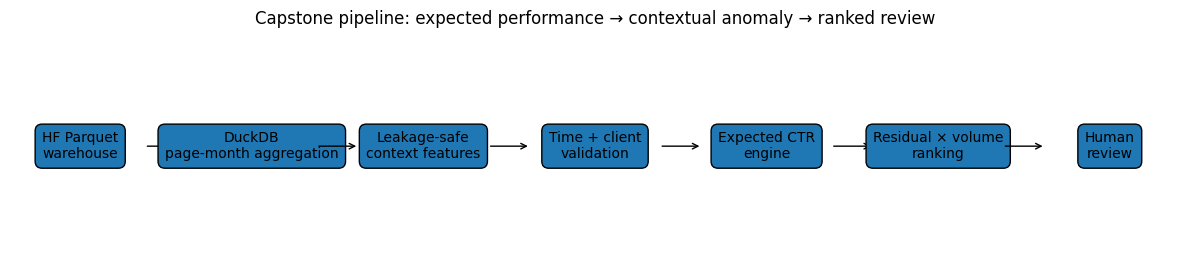

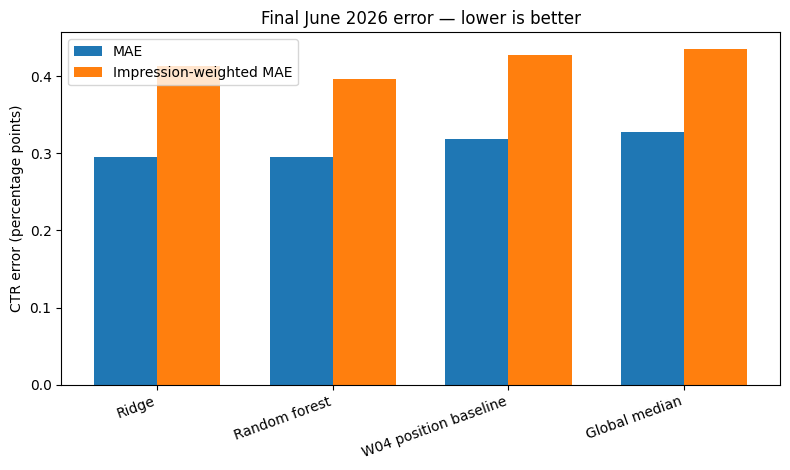

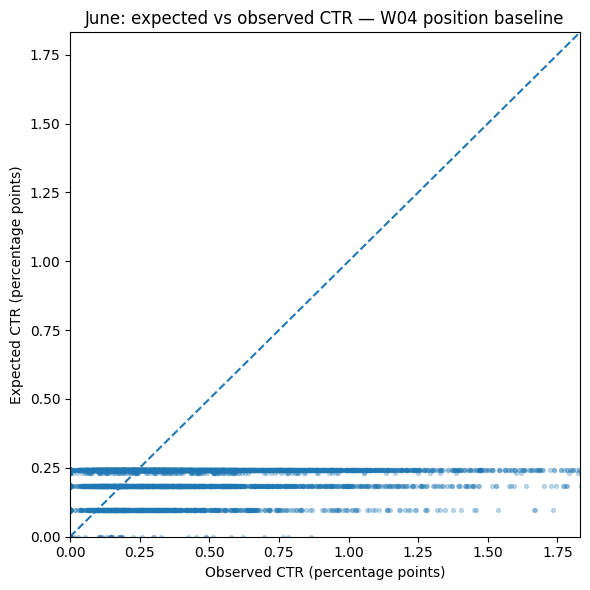

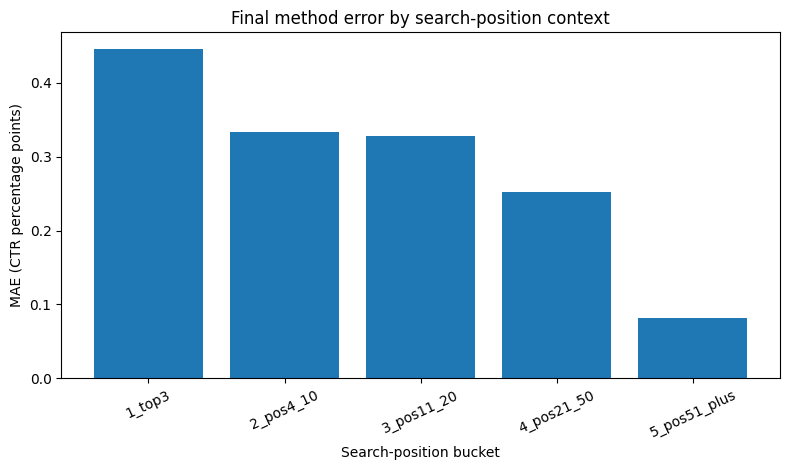

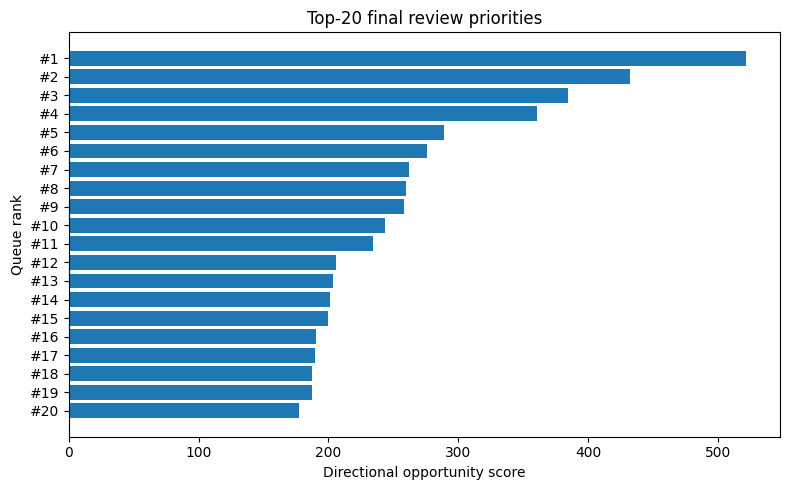

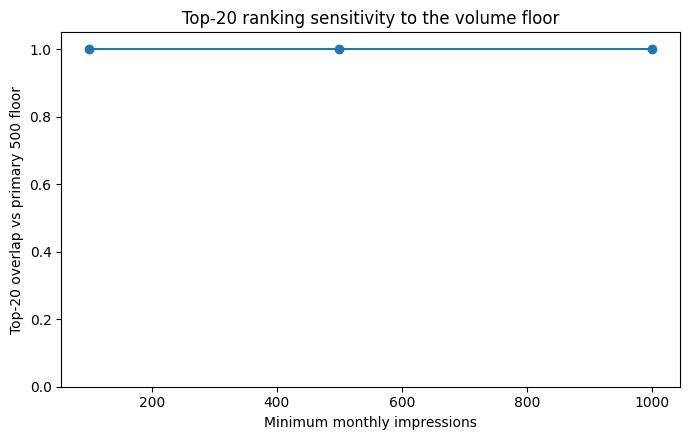

Saved figures:
 - /content/work/figures/01_pipeline.png
 - /content/work/figures/02_june_method_comparison.png
 - /content/work/figures/03_expected_vs_observed.png
 - /content/work/figures/04_error_by_position.png
 - /content/work/figures/05_top20_opportunity.png
 - /content/work/figures/06_volume_floor_stability.png


In [14]:
# Figure 1 — system pipeline
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

steps = [
    "HF Parquet\nwarehouse",
    "DuckDB\npage-month aggregation",
    "Leakage-safe\ncontext features",
    "Time + client\nvalidation",
    "Expected CTR\nengine",
    "Residual × volume\nranking",
    "Human\nreview",
]

xs = np.linspace(0.06, 0.94, len(steps))
for i, (x, label) in enumerate(zip(xs, steps)):
    ax.text(
        x, 0.5, label,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5"),
        transform=ax.transAxes,
    )
    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(xs[i+1] - 0.055, 0.5),
            xytext=(x + 0.055, 0.5),
            xycoords=ax.transAxes,
            textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->"),
        )

ax.set_title("Capstone pipeline: expected performance → contextual anomaly → ranked review")
fig.tight_layout()
fig.savefig(FIGURES / "01_pipeline.png", dpi=180, bbox_inches="tight")
plt.show()

# Figure 2 — final June method comparison
plot_cmp = june_comparison.sort_values("mae_pp").copy()
fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(plot_cmp))
width = 0.36
ax.bar(x - width/2, plot_cmp["mae_pp"], width, label="MAE")
ax.bar(x + width/2, plot_cmp["weighted_mae_pp"], width, label="Impression-weighted MAE")
ax.set_xticks(x)
ax.set_xticklabels(plot_cmp["method"], rotation=20, ha="right")
ax.set_ylabel("CTR error (percentage points)")
ax.set_title("Final June 2026 error — lower is better")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "02_june_method_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# Figure 3 — predicted vs observed for the chosen final engine
vis = test.copy()
vis["predicted_ctr_pp"] = chosen_june_pred
sample = vis.sample(n=min(6000, len(vis)), random_state=SEED)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    sample["observed_ctr_pp"],
    sample["predicted_ctr_pp"],
    s=8,
    alpha=0.25,
)
lim = float(
    np.nanpercentile(
        np.r_[sample["observed_ctr_pp"], sample["predicted_ctr_pp"]],
        99,
    )
)
lim = max(lim, 0.1)
ax.plot([0, lim], [0, lim], linestyle="--")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Observed CTR (percentage points)")
ax.set_ylabel("Expected CTR (percentage points)")
ax.set_title(f"June: expected vs observed CTR — {chosen_method}")
fig.tight_layout()
fig.savefig(FIGURES / "03_expected_vs_observed.png", dpi=180, bbox_inches="tight")
plt.show()

# Figure 4 — chosen final method error by position bucket
test_err = test[["position_bucket", "observed_ctr_pp"]].copy()
test_err["predicted_ctr_pp"] = chosen_june_pred
test_err["absolute_error_pp"] = (
    test_err["observed_ctr_pp"] - test_err["predicted_ctr_pp"]
).abs()

errpos = (
    test_err.groupby("position_bucket", observed=True)
    .agg(
        n=("absolute_error_pp", "size"),
        mae_pp=("absolute_error_pp", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(errpos["position_bucket"].astype(str), errpos["mae_pp"])
ax.set_ylabel("MAE (CTR percentage points)")
ax.set_xlabel("Search-position bucket")
ax.set_title("Final method error by search-position context")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES / "04_error_by_position.png", dpi=180, bbox_inches="tight")
plt.show()

# Figure 5 — top 20 opportunity scores
top20_plot = queue.head(20).copy()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    [f"#{i}" for i in top20_plot["rank"][::-1]],
    top20_plot["opportunity_score"][::-1],
)
ax.set_xlabel("Directional opportunity score")
ax.set_ylabel("Queue rank")
ax.set_title("Top-20 final review priorities")
fig.tight_layout()
fig.savefig(FIGURES / "05_top20_opportunity.png", dpi=180, bbox_inches="tight")
plt.show()

# Figure 6 — queue stability across volume floors
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    sensitivity["min_impressions"],
    sensitivity["top20_overlap_vs_500"],
    marker="o",
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Minimum monthly impressions")
ax.set_ylabel("Top-20 overlap vs primary 500 floor")
ax.set_title("Top-20 ranking sensitivity to the volume floor")
fig.tight_layout()
fig.savefig(FIGURES / "06_volume_floor_stability.png", dpi=180, bbox_inches="tight")
plt.show()

print("Saved figures:")
for p in sorted(FIGURES.glob("*.png")):
    print(" -", p)


## 13. Final quantitative receipts

The CSV queue is intentionally regenerable and should stay out of git.  
The JSON below contains only aggregate project metrics and should be committed.


In [15]:
def records_rounded(df, digits=8):
    clean = df.copy()
    for col in clean.select_dtypes(include=[np.number]).columns:
        clean[col] = clean[col].astype(float).round(digits)
    return clean.to_dict(orient="records")

may_base_row = row_for(may_comparison, "W04 position baseline")
june_base_row = row_for(june_comparison, "W04 position baseline")
june_chosen_row = row_for(june_comparison, chosen_method)

june_improvement_vs_baseline = (
    june_base_row["mae_pp"] - june_chosen_row["mae_pp"]
) / june_base_row["mae_pp"]

metrics = {
    "project_title": "Context-Aware Performance Anomaly Ranking",
    "lane": "CTR / Engagement Opportunity Scoring",
    "warehouse_release": "v20260703",
    "fact_table_rows_in_release": 78835655,
    "unit": "client_hash_id x content_hash_id x calendar month",
    "train_months": TRAIN_MONTHS,
    "validation_month": VALID_MONTH,
    "sealed_test_month": TEST_MONTH,
    "primary_min_impressions": PRIMARY_MIN_IMPRESSIONS,
    "action_max_position": ACTION_MAX_POSITION,
    "features": FEATURES,
    "w04_march_evidence": {
        "eligible_page_month_rows": 101441,
        "clients": 44,
        "ctr_vs_position_verdict": "CONFIRMED",
        "volume_verdict": "CONFIRMED",
        "ranked_candidates": 22185,
    },
    "split_rows": {
        "train": int(len(train)),
        "validation": int(len(valid)),
        "test": int(len(test)),
    },
    "may_comparison": records_rounded(may_comparison),
    "client_holdout_comparison": records_rounded(group_comparison),
    "best_learned_method": best_learned,
    "selected_final_method": chosen_method,
    "selection_reason": selection_reason,
    "may_mae_improvement_vs_w04": float(may_improvement),
    "client_holdout_mae_improvement_vs_w04": float(group_improvement),
    "june_comparison": records_rounded(june_comparison),
    "june_selected_mae_improvement_vs_w04": float(june_improvement_vs_baseline),
    "final_queue_candidates": int(len(queue)),
    "sensitivity": records_rounded(sensitivity),
    "random_seed": SEED,
    "claim_boundary": (
        "Observed contextual underperformance and directional decision support; "
        "no causal traffic uplift claim."
    ),
}

metrics_path = OUTPUTS / "capstone_metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2))

# The queue exists for reproducibility but should NOT be committed.
queue_path = OUTPUTS / "final_action_queue.csv"
queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "opportunity_score",
        "impressions",
        "avg_position",
        "observed_ctr_pp",
        "expected_ctr_pp",
        "ctr_gap_pp",
        "confidence",
        "reason_code",
        "suggested_action",
        "what_would_make_it_wrong",
    ]
].to_csv(queue_path, index=False)

print("✓ Metrics receipt:", metrics_path)
print("✓ Regenerable local queue:", queue_path, "(do NOT commit)")


✓ Metrics receipt: /content/work/outputs/capstone_metrics.json
✓ Regenerable local queue: /content/work/outputs/final_action_queue.csv (do NOT commit)


## 14. Generate the deployed research paper automatically

This cell creates a standalone GitHub Pages paper using the real numbers produced above.

The public page contains no client names, domains, URLs, query text, raw exports, or credentials. The top-ten recommendation table deliberately omits pseudonymous IDs too; it shows only rank and decision-relevant aggregate measurements.


In [16]:
# Copy public-safe figures into the GitHub Pages directory.
for fig_path in FIGURES.glob("*.png"):
    shutil.copy2(fig_path, ASSETS / fig_path.name)

(DOCS / ".nojekyll").write_text("")

def pct(x):
    return f"{100*x:.1f}%"

def f5(x):
    return f"{float(x):.5f}"

def safe_method_table(df):
    x = df[["method", "mae_pp", "weighted_mae_pp", "r2"]].copy()
    x.columns = ["Method", "MAE (pp)", "Weighted MAE (pp)", "R²"]
    return x.round(5).to_html(index=False, border=0, classes="data-table")

public_top10 = queue.head(10)[
    [
        "rank",
        "impressions",
        "avg_position",
        "observed_ctr_pp",
        "expected_ctr_pp",
        "ctr_gap_pp",
        "opportunity_score",
        "confidence",
        "reason_code",
        "suggested_action",
    ]
].copy()

public_top10.columns = [
    "Rank",
    "Impressions",
    "Avg position",
    "Observed CTR (pp)",
    "Expected CTR (pp)",
    "Gap (pp)",
    "Opportunity score",
    "Confidence",
    "Reason",
    "Suggested action",
]

for col in [
    "Avg position",
    "Observed CTR (pp)",
    "Expected CTR (pp)",
    "Gap (pp)",
    "Opportunity score",
]:
    public_top10[col] = public_top10[col].astype(float).round(4)

top10_html = public_top10.to_html(
    index=False,
    border=0,
    classes="data-table",
)

may_w04 = row_for(may_comparison, "W04 position baseline")
may_final = row_for(may_comparison, chosen_method)
june_w04 = row_for(june_comparison, "W04 position baseline")
june_final = row_for(june_comparison, chosen_method)

abstract_result = (
    f"On the sealed June 2026 test, the selected engine ({chosen_method}) "
    f"achieved MAE {june_final['mae_pp']:.4f} CTR percentage points versus "
    f"{june_w04['mae_pp']:.4f} for the frozen W04 position baseline "
    f"({pct(june_improvement_vs_baseline)} relative change in MAE)."
)

if chosen_method == "W04 position baseline":
    complexity_sentence = (
        "The learned models did not satisfy the predeclared complexity rule, "
        "so the transparent position-adjusted baseline was retained rather than "
        "claiming unnecessary ML value."
    )
else:
    complexity_sentence = (
        f"{chosen_method} satisfied the predeclared complexity rule before the final test "
        f"and was therefore retained as the expected-performance engine."
    )

html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Context-Aware Performance Anomaly Ranking — Muhammed Nehan</title>
<style>
:root {{
  --bg:#ffffff; --fg:#161616; --muted:#5b6470; --line:#d9dde3;
  --soft:#f5f7f9; --accent:#163d66;
}}
* {{ box-sizing:border-box; }}
body {{
  margin:0; font-family:Inter,ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
  color:var(--fg); background:var(--bg); line-height:1.65;
}}
main {{ width:min(1050px,92vw); margin:0 auto; padding:56px 0 90px; }}
header {{ padding-bottom:32px; border-bottom:1px solid var(--line); }}
.eyebrow {{ color:var(--accent); font-weight:700; letter-spacing:.05em; text-transform:uppercase; font-size:.82rem; }}
h1 {{ font-size:clamp(2.1rem,5vw,4.1rem); line-height:1.02; max-width:920px; margin:.3rem 0 1rem; }}
h2 {{ margin-top:54px; padding-top:12px; border-top:1px solid var(--line); }}
h3 {{ margin-top:30px; }}
p, li {{ font-size:1.02rem; }}
.lede {{ font-size:1.22rem; color:var(--muted); max-width:850px; }}
.note {{
  background:var(--soft); border-left:4px solid var(--accent);
  padding:15px 18px; margin:22px 0;
}}
.metric-grid {{
  display:grid; grid-template-columns:repeat(auto-fit,minmax(190px,1fr)); gap:14px; margin:24px 0;
}}
.metric {{
  border:1px solid var(--line); border-radius:10px; padding:16px;
}}
.metric b {{ display:block; font-size:1.45rem; }}
img {{ max-width:100%; height:auto; border:1px solid var(--line); border-radius:10px; margin:14px 0 24px; }}
.data-table {{ border-collapse:collapse; width:100%; font-size:.88rem; overflow:auto; display:block; }}
.data-table th,.data-table td {{ border-bottom:1px solid var(--line); padding:8px 10px; text-align:left; white-space:nowrap; }}
.data-table th {{ background:var(--soft); }}
code {{ background:var(--soft); padding:.1em .3em; border-radius:4px; }}
a {{ color:var(--accent); }}
footer {{ margin-top:60px; color:var(--muted); border-top:1px solid var(--line); padding-top:20px; }}
</style>
</head>
<body>
<main>
<header>
<div class="eyebrow">FlyRank ML Internship Capstone · Muhammed Nehan</div>
<h1>Context-Aware Performance Anomaly Ranking</h1>
<p class="lede">A leakage-safe system for learning expected search click-through performance, detecting high-impact under-capture, and producing an auditable human-review queue.</p>
</header>

<section id="abstract">
<h2>Abstract</h2>
<p>
Editorial teams need to decide which visible pages deserve limited review capacity, but raw CTR thresholds are unfair because expected CTR changes with search position, traffic volume, and measurement stability.
Using the FlyRank internship warehouse, this study aggregates daily search measurements into page-month observations and learns expected CTR from non-click operating context.
A frozen position-adjusted rule is compared with Ridge and Random Forest regression using later-time validation plus a held-out-client stress test, with June 2026 kept as the final sealed test month.
{abstract_result}
The resulting positive expected-minus-observed CTR residual is scaled by impressions to form a directional ranked review queue; the output is decision support only and does not imply that an edit will causally increase traffic.
</p>
</section>

<section id="introduction">
<h2>1. Introduction / Problem Statement</h2>
<p>
The operational question is simple: <strong>which existing pages should a human inspect first?</strong>
A universal CTR cutoff ignores the fact that a page near position 2 operates under a different click environment from a page near position 25.
The project therefore treats low CTR as a <em>contextual performance anomaly</em>: first estimate what CTR is normally observed under measured search conditions, then prioritize large negative deviations only when enough exposure exists for the difference to matter.
</p>
<div class="note">
<strong>Decision boundary.</strong> A score triggers review, not automatic publication. Query/SERP context, intent, seasonality, and content quality remain human checks.
</div>
<img src="assets/01_pipeline.png" alt="Capstone pipeline">
</section>

<section id="data">
<h2>2. Data</h2>
<p>
The source is the gated FlyRank internship warehouse release <strong>v20260703</strong>. Its daily performance fact contains 78,835,655 rows at report-date × client × content grain.
This study uses full monthly partitions from February through June 2026 and aggregates them to one pseudonymized client × content × month observation.
January is excluded because the warehouse begins on January 27 and is therefore not a comparable full calendar month.
</p>
<p>
Rows require valid GSC availability and at least {EXTRACT_MIN_IMPRESSIONS} monthly impressions for extraction. The primary model comparison uses at least {PRIMARY_MIN_IMPRESSIONS} impressions.
The target is observed CTR in percentage points: <code>100 × clicks / impressions</code>.
Clicks and CTR are never model inputs; IDs are grouping/audit keys only.
</p>
<div class="metric-grid">
<div class="metric"><span>Train rows</span><b>{len(train):,}</b><small>Feb–Apr 2026</small></div>
<div class="metric"><span>Validation rows</span><b>{len(valid):,}</b><small>May 2026</small></div>
<div class="metric"><span>Final test rows</span><b>{len(test):,}</b><small>June 2026</small></div>
<div class="metric"><span>Frozen W04 March candidates</span><b>22,185</b><small>transparent rule</small></div>
</div>
</section>

<section id="methodology">
<h2>3. Methodology</h2>
<p>
The feature vector contains only non-click search context available by the end of the scored month:
<code>{", ".join(FEATURES)}</code>.
This makes the task end-of-period contextual monitoring rather than future-month forecasting.
</p>
<p>
The frozen W04 baseline predicts the training-set median CTR for a page's position bucket.
Two learned alternatives are prespecified: regularized Ridge regression and a constrained Random Forest.
All preprocessing is fitted only on training rows.
The primary split trains on February–April and validates on May; a second grouped test holds out entire clients.
{complexity_sentence}
Only after this selection is frozen are all pre-June observations used to fit the final engines and June opened once for evaluation.
</p>
<h3>May validation</h3>
{safe_method_table(may_comparison)}
<h3>Held-out-client stress test</h3>
{safe_method_table(group_comparison)}
</section>

<section id="results">
<h2>4. Results</h2>
<p>{selection_reason}</p>
<p>{abstract_result}</p>
<h3>Final June comparison</h3>
{safe_method_table(june_comparison)}
<img src="assets/02_june_method_comparison.png" alt="June method comparison">
<img src="assets/03_expected_vs_observed.png" alt="Expected versus observed CTR">
<img src="assets/04_error_by_position.png" alt="Error by search position">
</section>

<section id="limitations">
<h2>5. Limitations & Honest Framing</h2>
<ul>
<li>The study is observational. A high opportunity score does not prove that changing metadata or content will increase clicks.</li>
<li>Expected CTR is learned from measured context, but unobserved query intent, SERP features, brand/navigation behavior, and seasonality can still explain apparent underperformance.</li>
<li>The model uses end-of-month context to monitor that month's performance; it is not a before-the-month traffic forecast.</li>
<li>Client histories are unbalanced and search measurement availability differs across clients.</li>
<li>The final June month is a one-period test. Continued deployment should monitor drift and later outcomes.</li>
</ul>
<p>A controlled rollout or A/B design would be required before making causal uplift claims.</p>
</section>

<section id="recommendations">
<h2>6. Ranked Recommendations</h2>
<p>
For June, the final method creates <strong>{len(queue):,}</strong> candidates after the primary eligibility rules.
The score is <code>max(expected CTR − observed CTR, 0) / 100 × impressions</code>.
It is best read as directional under-capture at meaningful exposure, not promised incremental clicks.
</p>
{top10_html}
<img src="assets/05_top20_opportunity.png" alt="Top 20 opportunity scores">
<h3>Stability</h3>
<p>
The queue is also rebuilt at 100, 500, and 1,000 monthly-impression floors without refitting the model, and top-20 overlap is reported as a sensitivity check.
</p>
<img src="assets/06_volume_floor_stability.png" alt="Ranking stability">
</section>

<section id="reproducibility">
<h2>7. Reproducibility</h2>
<p>
The full workflow is implemented in the capstone notebook: remote DuckDB aggregation over partitioned Parquet, frozen feature construction, time-aware validation, client-holdout stress testing, final June evaluation, queue construction, public-safe figures, and metric receipts.
</p>
<ul>
<li><a href="https://github.com/mnehan67/flyrank-ml-internship-starter">Repository</a></li>
<li><a href="https://github.com/mnehan67/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb">Capstone notebook</a></li>
<li>Random seed: {SEED}</li>
<li>Aggregate metric receipt: <code>work/outputs/capstone_metrics.json</code></li>
</ul>
</section>

<section id="acknowledgments">
<h2>8. Acknowledgments & Data Credit</h2>
<p>
Built on the <a href="https://flyrank.ai">FlyRank ML Internship dataset</a>.
The project uses pseudonymized search-performance data and intentionally excludes client names, domains, URLs, private queries, credentials, and raw warehouse exports from the public paper.
</p>
</section>

<footer>
<p>Muhammed Nehan · FlyRank ML Internship Capstone · Generated reproducibly from the committed notebook.</p>
</footer>
</main>
</body>
</html>
"""

paper_path = DOCS / "index.html"
paper_path.write_text(html, encoding="utf-8")

paper_url = "https://mnehan67.github.io/flyrank-ml-internship-starter/"
(SUBMISSION / "paper_url.txt").write_text(paper_url + "\n", encoding="utf-8")

print("✓ Generated paper:", paper_path)
print("✓ Mandatory paper URL file:", SUBMISSION / "paper_url.txt")
print("  ", paper_url)


✓ Generated paper: /content/docs/index.html
✓ Mandatory paper URL file: /content/submission/paper_url.txt
   https://mnehan67.github.io/flyrank-ml-internship-starter/


## 15. ML-12 closing material

### 5-minute demo outline

**0:00–0:40 — Problem.**  
Raw CTR is not comparable across operating conditions. The practical decision is which high-visibility pages a human should inspect first.

**0:40–1:20 — Data and leakage boundary.**  
Show the 78.8M-row warehouse, DuckDB monthly aggregation, non-click feature set, CTR target, and why clicks/CTR/IDs/future months are excluded from model inputs.

**1:20–2:20 — Baseline and models.**  
Show the frozen position-adjusted W04 baseline, Ridge, Random Forest, May time validation, and held-out-client stress test.

**2:20–3:20 — Final result.**  
Reveal the sealed June comparison and explain whether ML actually earned its complexity.

**3:20–4:20 — Ranked decision system.**  
Show expected CTR → residual → volume-scaled opportunity score → confidence/reason code → top review queue.

**4:20–5:00 — Limits and transferability.**  
Explain that this is observational decision support, not causal uplift; close with the general engineering pattern: learn expected behavior, detect contextual deviations, rank them by operational impact, keep a human in the loop.

### Social-post cut

I built a contextual performance-anomaly ranking system on FlyRank's large-scale search warehouse. Instead of applying a universal CTR threshold, the pipeline learns expected CTR from non-click search context, validates across later time and unseen clients, then ranks high-impact underperformance for human review. The project is leakage-safe, reproducible with DuckDB + scikit-learn, and explicitly separates directional monitoring from causal claims.

### 3-sentence employer-facing summary

I built a reproducible ML/analytics pipeline over a 78.8M-row operational-style warehouse using DuckDB, partitioned Parquet, time-aware validation, and client-holdout testing. The system learns expected performance from context, detects meaningful residual anomalies, and converts them into an explainable impact-ranked human-review queue. The same pattern transfers beyond search to network telemetry, infrastructure monitoring, fleet/transport operations, and other systems where teams need to find the most important underperforming entities first.


In [17]:
# Create a public-safe upload bundle.
# Intentionally exclude final_action_queue.csv and model binaries.

instructions = """FLYRANK CAPSTONE — FINAL SUBMISSION STEPS

1. Save the EXECUTED capstone notebook to:
   work/notebooks/capstone.ipynb

2. From this bundle, upload/commit:
   work/outputs/capstone_metrics.json
   work/figures/*.png
   docs/index.html
   docs/assets/*.png
   docs/.nojekyll
   submission/paper_url.txt

3. DO NOT commit:
   work/outputs/final_action_queue.csv
   any Hugging Face token
   any raw warehouse file

4. GitHub:
   Settings -> Pages -> Build and deployment
   Source: Deploy from a branch
   Branch: main
   Folder: /docs
   Save

5. Wait for Pages to deploy and open:
   https://mnehan67.github.io/flyrank-ml-internship-starter/

6. Confirm submission/paper_url.txt contains exactly:
   https://mnehan67.github.io/flyrank-ml-internship-starter/

7. Final capstone submission:
   https://github.com/mnehan67/flyrank-ml-internship-starter
"""

(ROOT / "CAPSTONE_SUBMISSION_STEPS.txt").write_text(instructions)

bundle_root = ROOT / "capstone_public_bundle"
if bundle_root.exists():
    shutil.rmtree(bundle_root)

(bundle_root / "work" / "outputs").mkdir(parents=True)
(bundle_root / "work" / "figures").mkdir(parents=True)
(bundle_root / "docs" / "assets").mkdir(parents=True)
(bundle_root / "submission").mkdir(parents=True)

shutil.copy2(
    OUTPUTS / "capstone_metrics.json",
    bundle_root / "work" / "outputs" / "capstone_metrics.json",
)

for p in FIGURES.glob("*.png"):
    shutil.copy2(p, bundle_root / "work" / "figures" / p.name)

shutil.copy2(DOCS / "index.html", bundle_root / "docs" / "index.html")
shutil.copy2(DOCS / ".nojekyll", bundle_root / "docs" / ".nojekyll")

for p in ASSETS.glob("*.png"):
    shutil.copy2(p, bundle_root / "docs" / "assets" / p.name)

shutil.copy2(
    SUBMISSION / "paper_url.txt",
    bundle_root / "submission" / "paper_url.txt",
)
shutil.copy2(
    ROOT / "CAPSTONE_SUBMISSION_STEPS.txt",
    bundle_root / "CAPSTONE_SUBMISSION_STEPS.txt",
)

zip_path = shutil.make_archive(
    str(ROOT / "capstone_submission_bundle"),
    "zip",
    root_dir=bundle_root,
)

print("✓ FINAL PUBLIC BUNDLE CREATED:")
print(zip_path)
print("\nThe only remaining manual work after this notebook succeeds:")
print("1) save this executed notebook to GitHub")
print("2) upload the bundle files")
print("3) enable GitHub Pages from /docs")
print("4) submit your repo URL")


✓ FINAL PUBLIC BUNDLE CREATED:
/content/capstone_submission_bundle.zip

The only remaining manual work after this notebook succeeds:
1) save this executed notebook to GitHub
2) upload the bundle files
3) enable GitHub Pages from /docs
4) submit your repo URL


## 16. Final self-check

Before submitting, confirm:

- [ ] Notebook ran from top to bottom with **no errors**.
- [ ] May validation table is visible.
- [ ] Client-holdout table is visible.
- [ ] Final method was chosen **before** June.
- [ ] June comparison table is visible.
- [ ] Ranked June queue has at least 10 rows.
- [ ] Volume-floor sensitivity table is visible.
- [ ] Six public-safe figures were generated.
- [ ] `work/outputs/capstone_metrics.json` exists.
- [ ] `docs/index.html` exists.
- [ ] `submission/paper_url.txt` contains exactly one URL line.
- [ ] No raw dataset, queue CSV, token, client name, domain, URL, or private query is committed.
- [ ] Executed notebook is committed as `work/notebooks/capstone.ipynb`.
- [ ] GitHub Pages is enabled from `main /docs`.
- [ ] Deployed paper opens publicly.
- [ ] Final submission is the repo URL.

### Final submission URL

`https://github.com/mnehan67/flyrank-ml-internship-starter`
